In [2]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


TRAIN_DIR     = "apple_dataset/train"

VAL_DIR     = "apple_dataset/val"
TEST_DIR    = "apple_dataset/test"

CLASS_NAMES   = ["apple_leaf_healthy", "apple_rust_leaf", "apple_scab_leaf", "apple_frogeye_leaf_spot", "apple_mosaic_leaf", "apple_powdery_mildew_leaf"]
IMG_SIZE      = (224, 224)
BATCH_SIZE    = 16
EPOCHS        = 60
LEARNING_RATE = 1e-3
SEED          = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.21.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
def load_datasets():
    def make_ds(directory_path, shuffle):
        return keras.utils.image_dataset_from_directory(
            directory_path,
            image_size=IMG_SIZE,
            batch_size=BATCH_SIZE,
            label_mode="categorical",
            shuffle=shuffle,
            seed=SEED,
        )

    train_ds = make_ds(TRAIN_DIR, shuffle=True)
    val_ds   = make_ds(VAL_DIR,   shuffle=False)
    test_ds  = make_ds(TEST_DIR,  shuffle=False)
    
    return train_ds, val_ds, test_ds

raw_train_ds, raw_val_ds, raw_test_ds = load_datasets()

Found 1043 files belonging to 6 classes.


I0000 00:00:1781987601.253392   11498 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4149 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Found 233 files belonging to 6 classes.
Found 232 files belonging to 6 classes.


In [4]:

augmentation_layer = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    layers.RandomBrightness(0.15),
    layers.RandomContrast(0.15),
], name="data_augmentation")

def preprocess_train(images, labels):
    images = tf.cast(images, tf.float32) 
    images = augmentation_layer(images, training=True)
    return images, labels

def preprocess_eval(images, labels):
    images = tf.cast(images, tf.float32) 
    return images, labels

AUTOTUNE = tf.data.AUTOTUNE

train_ds = (raw_train_ds
            .map(preprocess_train, num_parallel_calls=AUTOTUNE)
            .prefetch(AUTOTUNE))

val_ds   = (raw_val_ds
            .map(preprocess_eval,  num_parallel_calls=AUTOTUNE)
            .prefetch(AUTOTUNE).cache())

test_ds  = (raw_test_ds
            .map(preprocess_eval,  num_parallel_calls=AUTOTUNE)
            .prefetch(AUTOTUNE).cache())

In [5]:

def build_model(num_classes=3):
    base_model = keras.applications.EfficientNetB0(
        input_shape=(*IMG_SIZE, 3),
        include_top=False,
        weights="imagenet"
    )

    base_model.trainable = True
    total_layers = len(base_model.layers)
    freezing_ratio = 0.7
    fine_tune_at = int(freezing_ratio * total_layers)

    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False

    inputs = keras.Input(shape=(*IMG_SIZE, 3))

    x = base_model(inputs, training=False) 
    
    from tensorflow.keras import regularizers

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(
        num_classes, 
        activation="softmax",
        kernel_regularizer=regularizers.l2(0.1)
    )(x)

    return keras.Model(inputs, outputs, name="AppleLeaf_EfficientNetB0")

model = build_model(num_classes=len(CLASS_NAMES))
model.summary()

Model: "AppleLeaf_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,057,257 (15.48 MB)

 Trainable params: 3,086,818 (11.78 MB)

 Non-trainable params: 970,439 (3.70 MB)

In [6]:

def get_callbacks():
    return [
        keras.callbacks.ModelCheckpoint(
            "best_model.keras",
            monitor="val_accuracy",
            save_best_only=True,
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=15,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=7,
            min_lr=1e-7,
            verbose=1,
        ),
    ]

def plot_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history["accuracy"],     label="Train")
    axes[0].plot(history.history["val_accuracy"], label="Val")
    axes[0].set_title("Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history["loss"],     label="Train")
    axes[1].plot(history.history["val_loss"], label="Val")
    axes[1].set_title("Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

Epoch 1/60


I0000 00:00:1781987625.291338   11952 service.cc:153] XLA service 0x7e740407edc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781987625.291441   11952 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1781987626.108310   11952 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1781987627.871747   11952 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1781987628.247114   11952 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_26480__.316
E0000 00:00:1781987632.079752   11952 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 3/66 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.2708 - loss: 2.9726  

I0000 00:00:1781987647.038530   11952 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


65/66 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6104 - loss: 2.0853

I0000 00:00:1781987651.333679   11951 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_26480__.316


66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 0.6119 - loss: 2.0781

E0000 00:00:1781987672.523186   11951 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_accuracy improved from None to 0.83262, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 63s 477ms/step - accuracy: 0.7085 - loss: 1.6124 - val_accuracy: 0.8326 - val_loss: 0.8957 - learning_rate: 0.0010
Epoch 2/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8576 - loss: 0.8093
Epoch 2: val_accuracy improved from 0.83262 to 0.87124, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.8773 - loss: 0.7024 - val_accuracy: 0.8712 - val_loss: 0.6618 - learning_rate: 0.0010
Epoch 3/60
64/66 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8648 - loss: 0.5722
Epoch 3: val_accuracy did not improve from 0.87124
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.8811 - loss: 0.5092 - val_accuracy: 0.8498 - val_loss: 0.5553 - learning_rate: 0.0010
Epoch 4/60
65/66 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9066 - loss:

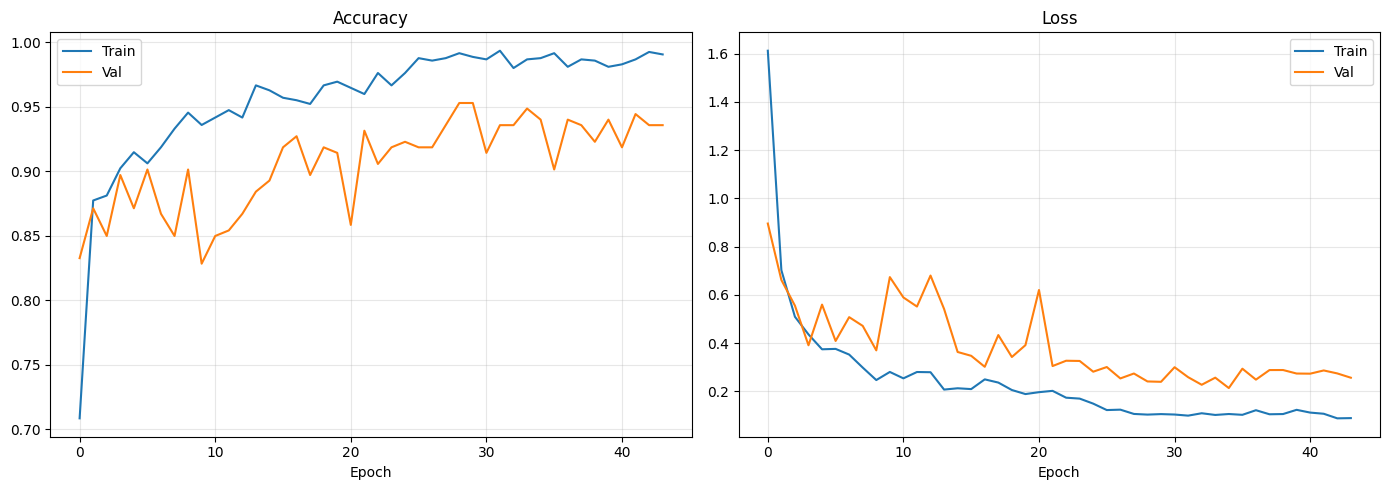

In [7]:

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=get_callbacks(),
)

plot_history(history)


══ Final Evaluation on Test Set ══
11/15 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9861 - loss: 0.1322

E0000 00:00:1781988349.813728   11954 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 650ms/step - accuracy: 0.9483 - loss: 0.2841
Test Loss:     0.2841
Test Accuracy: 0.9483

── Classification Report ──
                           precision    recall  f1-score   support

       apple_leaf_healthy       1.00      1.00      1.00        38
          apple_rust_leaf       0.89      0.97      0.93        40
          apple_scab_leaf       1.00      1.00      1.00        38
  apple_frogeye_leaf_spot       1.00      0.95      0.97        38
        apple_mosaic_leaf       0.86      0.95      0.90        39
apple_powdery_mildew_leaf       0.97      0.82      0.89        39

                 accuracy                           0.95       232
                macro avg       0.95      0.95      0.95       232
             weighted avg       0.95      0.95      0.95       232



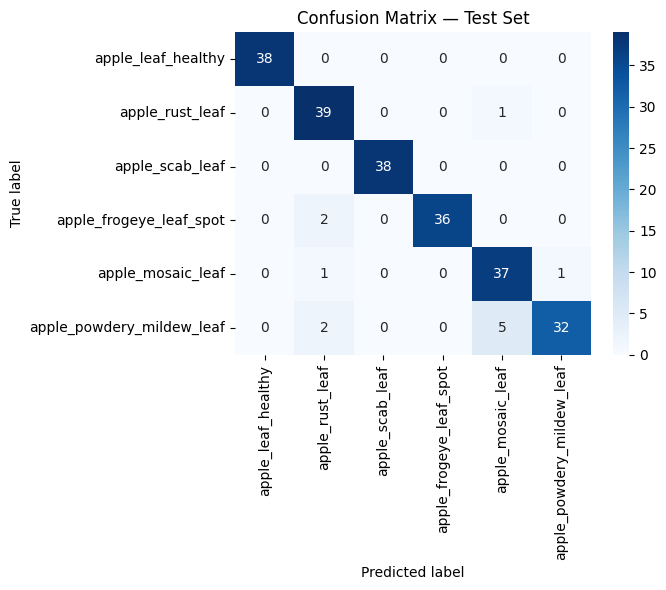


Model saved → apple_leaf_model_final.keras


In [8]:
def evaluate_test(model, test_ds):
    print("\n══ Final Evaluation on Test Set ══")
    test_loss, test_acc = model.evaluate(test_ds, verbose=1)
    print(f"Test Loss:     {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")

    y_true, y_pred = [], []
    for images, labels in test_ds:
        preds = model.predict(images, verbose=0)
        y_true.extend(np.argmax(labels.numpy(), axis=1))
        y_pred.extend(np.argmax(preds, axis=1))

    print("\n── Classification Report ──")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.title("Confusion Matrix — Test Set")
    plt.tight_layout()
    plt.show()

evaluate_test(model, test_ds)

model.save("apple_leaf_model_final.keras")
print("\nModel saved → apple_leaf_model_final.keras")